<a href="https://colab.research.google.com/github/vituhaa/Multimodal-Reasoning-for-STEM/blob/main/Multimodal_Reasoning_for_STEM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Qwen/Qwen3-VL-2B-Instruct

Qwen/Qwen3-VL-4B-Instruct

HuggingFaceTB/SmolVLM-256M Instruct

google/t5gemma-2-270m-270m

"HuggingFaceTB/SmolVLM-256M Instruct" model was selected to fine-tune.

Photo example from  [linxy/LaTeX_OCR dataset](https://huggingface.co/datasets/linxy/LaTeX_OCR/viewer/human_handwrite?views%5B%5D=human_handwrite_train):

sinx - siny - sin(x - y)

In [ ]:
! nvidia-smi

Thu Mar 19 12:41:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
! pip install -U bitsandbytes>=0.46.1

После этой ячейки нужно обязательно перезапустить сеанс.

Zero-shot inference

In [1]:
import torch
import requests
from PIL import Image
from transformers import AutoProcessor, AutoModelForImageTextToText
from transformers.image_utils import load_image
from io import BytesIO
from peft import PeftModel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "HuggingFaceTB/SmolVLM-256M-Instruct"

In [ ]:
image_path = "/content/formula.jpg"
image = load_image(image_path)

processor = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM-256M-Instruct")
model = AutoModelForImageTextToText.from_pretrained(
    model_name,
    dtype=torch.bfloat16,
    _attn_implementation="eager"
).to(DEVICE)

input_messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "Convert this hand-written mathematical formula into LaTex format."}
        ]
    }
]

prompt = processor.apply_chat_template(input_messages, add_generation_prompt=True)
inputs = processor(text=prompt, images=[image], return_tensors="pt")
inputs = inputs.to(DEVICE)

generated_ids = model.generate(**inputs, max_new_tokens=128)
generated_texts = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True,
)

print(generated_texts[0])

One-shot inference

In [ ]:
example_image_path = "/content/example.jpg"
inference_image_path = "/content/inference.jpg"
example_image = load_image(example_image_path)
inference_image = load_image(inference_image_path)

processor = AutoProcessor.from_pretrained(model_name)
model = AutoModelForImageTextToText.from_pretrained(
    model_name,
    dtype=torch.bfloat16,
    _attn_implementation="eager"
).to(DEVICE)

input_messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "Convert this hand-written mathematical formula into LaTex format."}
        ]
    },
    {
        "role": "assistant",
        "content": [
            {"type": "text", "text": "\log z = \log r + i ( \theta + 2 n \pi )"}
        ]
    },
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "Convert this hand-written mathematical formula into LaTex format."}
        ]
    }
]

prompt = processor.apply_chat_template(input_messages, add_generation_prompt=True)
inputs = processor(text=prompt, images=[example_image, inference_image], return_tensors="pt")
inputs = inputs.to(DEVICE)

generated_ids = model.generate(**inputs, max_new_tokens=500)
generated_texts = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True,
)

print(*generated_texts)

Supervised fine-tuning (SFT) using linxy/LaTeX_OCR:train

In [ ]:
from datasets import load_dataset

train_raw = load_dataset("linxy/LaTeX_OCR", name="human_handwrite", split="train")
test_raw = load_dataset("linxy/LaTeX_OCR", name="human_handwrite", split="test")

In [ ]:
from transformers import BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

processor = AutoProcessor.from_pretrained(model_name)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

model = AutoModelForImageTextToText.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
    _attn_implementation="eager"
)

In [ ]:
model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=['down_proj','o_proj','k_proj','q_proj','gate_proj','up_proj','v_proj'],
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

In [ ]:
def preprocess_dataset(example):
  image = example["image"]
  latex_output = example["text"]
  messages = [
      {
          "role": "user",
          "content": [
            {"type": "image"},
            {"type": "text", "text": "Convert this hand-written mathematical formula into LaTex format."}
          ]
      },
      {
          "role": "assistant",
          "content": [{"type": "text", "text": latex_output}]
      }
  ]
  prompt = processor.apply_chat_template(messages, add_generation_prompt=False)
  return {
      "images": [image],
      "texts": prompt
  }

train_dataset = train_raw.map(preprocess_dataset)
test_dataset = test_raw.map(preprocess_dataset)

In [6]:
def collate_fn(examples):
  texts = []
  images = []
  for example in examples:
      images.extend(example['images'])
      texts.append(example['texts'])

  batch = processor(text=texts, images=images, return_tensors="pt", padding=True)
  batch['labels'] = batch['input_ids'].clone()

  return batch

https://huggingface.co/docs/transformers/v5.3.0/en/main_classes/trainer#transformers.TrainingArguments

In [7]:
from transformers import TrainingArguments, Trainer, tokenization_utils_base

training_args = TrainingArguments(
    output_dir="./smolvlm_latex",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    num_train_epochs=1,
    learning_rate=2e-4,
    warmup_steps=50,
    optim="paged_adamw_8bit",
    weight_decay=0.01,
    gradient_accumulation_steps=4,
    fp16=True,
    bf16=False,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    remove_unused_columns=False,
    dataloader_num_workers=2
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=collate_fn
)

In [8]:
trainer.train()
trainer.save_model("./smolvlm-fine-tuned")
processor.save_pretrained("./smolvlm-fine-tuned")

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
100,0.045616,0.044106
200,0.026856,0.026374
300,0.019067,0.016990


['./smolvlm-fine-tuned/processor_config.json']

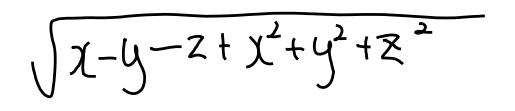

Настоящая LaTex формула:  \sqrt { x - y - z + x ^ { 2 } + y ^ { 2 } + z ^ { 2 } }
Предсказанная LaTex формула:  Assistant: \sqrt { x - y - z + x ^ { 2 } + y ^ { 2 } + z ^ { 2 } }


In [9]:
def check(image):
  prompt = "Convert this hand-written mathematical formula into LaTex format."
  messages = [
      {
          "role": "user",
          "content": [
            {"type": "image"},
            {"type": "text", "text": prompt}
          ]
      }
  ]
  prompt = processor.apply_chat_template(messages, add_generation_prompt=False)
  inputs = processor(images=[image], text=prompt, return_tensors="pt").to(DEVICE)

  generated_ids = model.generate(**inputs, max_new_tokens=256)
  generated_ids = generated_ids[:, inputs['input_ids'].shape[1]:]
  generated_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
  return generated_texts

test_photo = test_dataset[1]
test_img = test_photo['image']
test_formula = test_photo['text']

display(test_img)
prediction = check(test_img)

print("Настоящая LaTex формула: ", test_formula)
print("Предсказанная LaTex формула: ", prediction)


In [10]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
nltk.download('punkt_tab', quiet=True)

def find_bleu(pred, true):
  smoothing = SmoothingFunction().method4
  bleu_score = sentence_bleu([true.split()], pred.split(), smoothing_function=smoothing)
  return bleu_score

pred = prediction
true = test_formula
bleu = find_bleu(pred, true)
print("BLEU Score: ", bleu)

BLEU Score:  0.960707139034002


In [ ]:
# сохраняю модель:
from huggingface_hub import notebook_login, HfApi

model_0 = AutoModelForImageTextToText.from_pretrained(model_name)
fn_model = PeftModel.from_pretrained(model_0, "vituuha/smolvlm-fine-tuned")
merged_model = fn_model.merge_and_unload()

merged_model.save_pretrained("./full_model_fn")
AutoProcessor.from_pretrained("vituuha/smolvlm-fine-tuned").save_pretrained("./full_model_fn")

notebook_login()
api = HfApi()
api.create_repo(repo_id="vituuha/smolvlm-full", exist_ok=True, private=False)
HfApi().upload_folder(folder_path="./full_model_fn", repo_id="vituuha/smolvlm-full", repo_type="model")